In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas ✅")

Librerías cargadas ✅


In [2]:
df = pd.read_csv("data.csv", encoding="latin1")

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras filas:")
df.head()

Shape: (541909, 8)

Columnas: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Tipos de datos:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Primeras filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print("=== Valores nulos ===")
print(df.isnull().sum())

print("\n=== CustomerID nulos (%) ===")
print(f"{df['CustomerID'].isnull().sum() / len(df) * 100:.1f}%")

print("\n=== Quantities negativas (devoluciones) ===")
print(f"{(df['Quantity'] < 0).sum()} filas")

print("\n=== Precios en cero ===")
print(f"{(df['UnitPrice'] <= 0).sum()} filas")

print("\n=== Países únicos ===")
print(df['Country'].nunique())
print(df['Country'].value_counts().head(5))

=== Valores nulos ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== CustomerID nulos (%) ===
24.9%

=== Quantities negativas (devoluciones) ===
10624 filas

=== Precios en cero ===
2517 filas

=== Países únicos ===
38
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64


In [4]:
# Tamaño original
print(f"Filas originales: {len(df):,}")

# Eliminar filas sin CustomerID
df = df.dropna(subset=["CustomerID"])

# Eliminar devoluciones y precios en cero
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

# Convertir tipos
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Crear columna de revenue por línea
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Filas después de limpieza: {len(df):,}")
print(f"Filas eliminadas: {541909 - len(df):,}")
print(f"Clientes únicos: {df['CustomerID'].nunique():,}")
print(f"Rango de fechas: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

Filas originales: 541,909
Filas después de limpieza: 397,884
Filas eliminadas: 144,025
Clientes únicos: 4,338
Rango de fechas: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


In [5]:
# Fecha de referencia: un día después de la última transacción
fecha_referencia = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (fecha_referencia - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)

print("=== RFM calculado ===")
print(rfm.shape)
print(rfm.describe().round(2))

=== RFM calculado ===
(4338, 4)
       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2054.27
std       1721.81   100.01       7.70    8989.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     307.41
50%      15299.50    51.00       2.00     674.48
75%      16778.75   142.00       5.00    1661.74
max      18287.00   374.00     209.00  280206.02


In [6]:
# Scores del 1 al 5 (5 = mejor)
# Recency: menos días = mejor (score invertido)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])

# Score combinado
rfm["RFM_Score"] = (rfm["R_Score"].astype(int) + 
                    rfm["F_Score"].astype(int) + 
                    rfm["M_Score"].astype(int))

# Segmentación
def segmentar(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r >= 3 and f <= 2 and m <= 2:
        return "Promising"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    elif r == 1 and f <= 2 and m <= 2:
        return "Lost"
    else:
        return "Need Attention"

rfm["Segment"] = rfm.apply(segmentar, axis=1)

print("=== Distribución de Segmentos ===")
print(rfm["Segment"].value_counts())
print(f"\nTotal clientes: {len(rfm):,}")

=== Distribución de Segmentos ===
Segment
Need Attention     1041
Champions           962
Loyal Customers     758
Lost                556
At Risk             454
New Customers       319
Promising           248
Name: count, dtype: int64

Total clientes: 4,338


In [7]:
resumen = rfm.groupby("Segment").agg(
    Clientes=("CustomerID", "count"),
    Recency_Avg=("Recency", "mean"),
    Frequency_Avg=("Frequency", "mean"),
    Monetary_Avg=("Monetary", "mean"),
    Monetary_Total=("Monetary", "sum")
).reset_index()

resumen["Recency_Avg"] = resumen["Recency_Avg"].round(0).astype(int)
resumen["Frequency_Avg"] = resumen["Frequency_Avg"].round(1)
resumen["Monetary_Avg"] = resumen["Monetary_Avg"].round(0).astype(int)
resumen["Monetary_Total"] = resumen["Monetary_Total"].round(0).astype(int)
resumen["Revenue %"] = (resumen["Monetary_Total"] / resumen["Monetary_Total"].sum() * 100).round(1)

resumen = resumen.sort_values("Monetary_Total", ascending=False)

print("=== Resumen por Segmento ===")
print(resumen.to_string(index=False))

=== Resumen por Segmento ===
        Segment  Clientes  Recency_Avg  Frequency_Avg  Monetary_Avg  Monetary_Total  Revenue %
      Champions       962           13           11.1          6039         5809341       65.2
Loyal Customers       758           36            4.1          1843         1396691       15.7
        At Risk       454          142            3.8          1635          742150        8.3
 Need Attention      1041          118            1.7           603          627950        7.0
  New Customers       319           19            1.2           458          146167        1.6
           Lost       556          280            1.0           227          126405        1.4
      Promising       248           53            1.1           253           62704        0.7


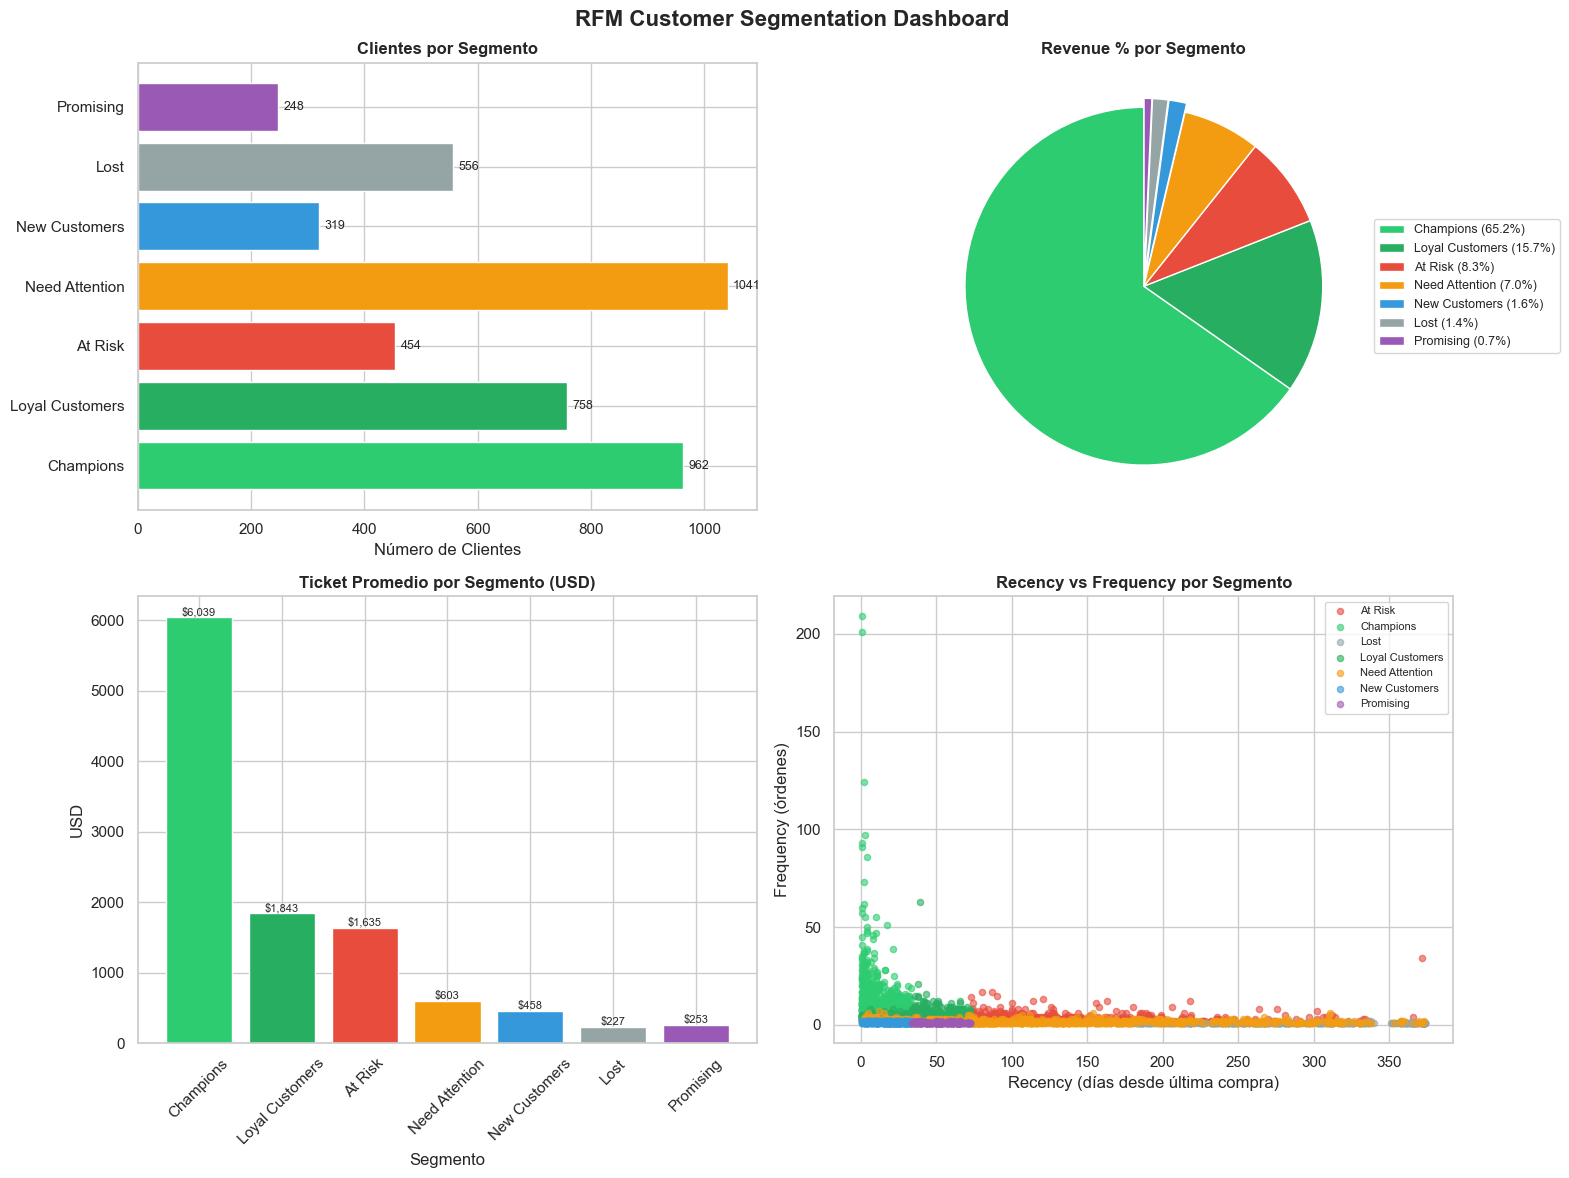

Gráfico guardado ✅


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("RFM Customer Segmentation Dashboard", fontsize=16, fontweight="bold")

# Paleta de colores por segmento
colores = {
    "Champions": "#2ecc71",
    "Loyal Customers": "#27ae60",
    "At Risk": "#e74c3c",
    "Need Attention": "#f39c12",
    "New Customers": "#3498db",
    "Lost": "#95a5a6",
    "Promising": "#9b59b6"
}
color_list = [colores[s] for s in resumen["Segment"]]

# ── Gráfico 1: Clientes por Segmento ──────────────────────────
ax1 = axes[0, 0]
bars = ax1.barh(resumen["Segment"], resumen["Clientes"], color=color_list)
ax1.set_title("Clientes por Segmento", fontweight="bold")
ax1.set_xlabel("Número de Clientes")
for bar, val in zip(bars, resumen["Clientes"]):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9)

# ── Gráfico 2: Revenue % por Segmento ─────────────────────────
ax2 = axes[0, 1]

# Separar segmentos chicos para que se lean mejor
explode = [0.05 if v < 5 else 0 for v in resumen["Revenue %"]]

wedges, texts = ax2.pie(
    resumen["Revenue %"],
    colors=color_list,
    startangle=90,
    explode=explode,
    pctdistance=0.85,
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda afuera del pie
ax2.legend(
    wedges,
    [f"{s} ({v:.1f}%)" for s, v in zip(resumen["Segment"], resumen["Revenue %"])],
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=9
)
ax2.set_title("Revenue % por Segmento", fontweight="bold")

# ── Gráfico 3: Monetary Promedio por Segmento ─────────────────
ax3 = axes[1, 0]
bars3 = ax3.bar(resumen["Segment"], resumen["Monetary_Avg"], color=color_list)
ax3.set_title("Ticket Promedio por Segmento (USD)", fontweight="bold")
ax3.set_xlabel("Segmento")
ax3.set_ylabel("USD")
ax3.tick_params(axis="x", rotation=45)
for bar, val in zip(bars3, resumen["Monetary_Avg"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f"${val:,}", ha="center", fontsize=8)

# ── Gráfico 4: Recency vs Frequency (scatter) ─────────────────
ax4 = axes[1, 1]
for segmento, grupo in rfm.groupby("Segment"):
    ax4.scatter(grupo["Recency"], grupo["Frequency"],
                label=segmento, alpha=0.6, s=20,
                color=colores.get(segmento, "#333333"))
ax4.set_title("Recency vs Frequency por Segmento", fontweight="bold")
ax4.set_xlabel("Recency (días desde última compra)")
ax4.set_ylabel("Frequency (órdenes)")
ax4.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("rfm_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado ✅")

In [12]:
with pd.ExcelWriter("rfm_results.xlsx") as writer:
    rfm.to_excel(writer, sheet_name="RFM Scores", index=False)
    resumen.to_excel(writer, sheet_name="Resumen por Segmento", index=False)

print("Excel exportado ✅")

Excel exportado ✅
